# GR00T Inference

This tutorial shows how to use the GR00T inference model to predict the actions from the observations, given a test dataset.

In [2]:
import os
import torch
import gr00t

from gr00t.data.dataset import LeRobotSingleDataset
from gr00t.model.policy import Gr00tPolicy

/home/ergocub/miniforge3/envs/conda-gr00t/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-01 14:55:15.133739: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-01 14:55:15.140240: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751374515.148470  314469 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751374515.152105  314469 cuda_bl

In [7]:
# change the following paths
MODEL_PATH = "nvidia/GR00T-N1.5-3B"
MODEL_PATH = "/home/ergocub/G1-checkpoints"

# REPO_PATH is the path of the pip install gr00t repo and one level up
REPO_PATH = os.path.dirname(os.path.dirname(gr00t.__file__))
DATASET_PATH = os.path.join(REPO_PATH, "demo_data/g1")
EMBODIMENT_TAG = "new_embodiment"

device = "cuda" if torch.cuda.is_available() else "cpu"

## Loading Pretrained Policy

Policy Model is loaded just like any other huggingface model.

There are 2 new concepts here in the GR00T model:
 - modality config: This defines the keys in the dictionary used by the model. (e.g. `action`, `state`, `annotation`, `video`)
 - modality_transform: A sequence of transform which are used during dataloading

In [8]:
from gr00t.experiment.data_config import DATA_CONFIG_MAP


data_config = DATA_CONFIG_MAP["unitree_g1"]
modality_config = data_config.modality_config()
modality_transform = data_config.transform()

policy = Gr00tPolicy(
    model_path=MODEL_PATH,
    embodiment_tag=EMBODIMENT_TAG,
    modality_config=modality_config,
    modality_transform=modality_transform,
    device=device,
)

# print out the policy model architecture
print(policy.model)

Model not found or avail in the huggingface hub. Loading from local path: /home/ergocub/G1-checkpoints
Loading pretrained dual brain from /home/ergocub/G1-checkpoints
Tune backbone vision tower: True
Tune backbone LLM: False
Tune action head projector: True
Tune action head DiT: True
Model not found or avail in the huggingface hub. Loading from local path: /home/ergocub/G1-checkpoints
/home/ergocub/G1-checkpoints
Tune backbone llm: False
Tune backbone visual: True
Total number of DiT parameters:  550386688
Total number of SelfAttentionTransformer parameters:  201433088
Tune action head projector: True
Tune action head diffusion model: True


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  4.66it/s]


pretrained model action_horizon 16
pretrained model action_dim 32
Tune backbone llm: False
Tune backbone visual: True
Tune action head projector: True
Tune action head diffusion model: True
kwargs = {'torch_dtype': torch.bfloat16}
pretrained model action_horizon 16
pretrained model action_dim 32
Tune Projector True
Loaded metadata from /home/ergocub/G1-checkpoints/experiment_cfg/metadata.json
Applying to: ['state.left_arm', 'state.right_arm', 'state.left_hand', 'state.right_hand']
Modality metadata: {}
Applying to: ['action.left_arm', 'action.right_arm', 'action.left_hand', 'action.right_hand']
Modality metadata: {}
GR00T_N1_5(
  (backbone): EagleBackbone(
    (eagle_model): Eagle2_5_VLForConditionalGeneration(
      (vision_model): SiglipVisionModel(
        (vision_model): SiglipVisionTransformer(
          (embeddings): SiglipVisionEmbeddings(
            (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
            (position_embedding): Embedd

## Loading dataset

First this requires user to check which embodiment tags are used to pretrained the `Gr00tPolicy` pretrained models.

In [9]:
import numpy as np

modality_config = policy.modality_config

print(modality_config.keys())

for key, value in modality_config.items():
    if isinstance(value, np.ndarray):
        print(key, value.shape)
    else:
        print(key, value)


dict_keys(['video', 'state', 'action', 'language'])
video delta_indices=[0] modality_keys=['video.rs_view']
state delta_indices=[0] modality_keys=['state.left_arm', 'state.right_arm', 'state.left_hand', 'state.right_hand']
action delta_indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] modality_keys=['action.left_arm', 'action.right_arm', 'action.left_hand', 'action.right_hand']
language delta_indices=[0] modality_keys=['annotation.human.task_description']


In [10]:
# Create the dataset
dataset = LeRobotSingleDataset(
    dataset_path=DATASET_PATH,
    modality_configs=modality_config,
    video_backend="torchvision_av",
    video_backend_kwargs=None,
    transforms=None,  # We'll handle transforms separately through the policy
    embodiment_tag=EMBODIMENT_TAG,
)

modality = 'state'
modality = 'action'
self.dataset_name = 'g1'
self.all_steps = [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17), (0, 18), (0, 19), (0, 20), (0, 21), (0, 22), (0, 23), (0, 24), (0, 25), (0, 26), (0, 27), (0, 28), (0, 29), (0, 30), (0, 31), (0, 32), (0, 33), (0, 34), (0, 35), (0, 36), (0, 37), (0, 38), (0, 39), (0, 40), (0, 41), (0, 42), (0, 43), (0, 44), (0, 45), (0, 46), (0, 47), (0, 48), (0, 49), (0, 50), (0, 51), (0, 52), (0, 53), (0, 54), (0, 55), (0, 56), (0, 57), (0, 58), (0, 59), (0, 60), (0, 61), (0, 62), (0, 63), (0, 64), (0, 65), (0, 66), (0, 67), (0, 68), (0, 69), (0, 70), (0, 71), (0, 72), (0, 73), (0, 74), (0, 75), (0, 76), (0, 77), (0, 78), (0, 79), (0, 80), (0, 81), (0, 82), (0, 83), (0, 84), (0, 85), (0, 86), (0, 87), (0, 88), (0, 89), (0, 90), (0, 91), (0, 92), (0, 93), (0, 94), (0, 95), (0, 96), (0, 97), (0, 98), (0, 99), (0, 100), (0, 101), (0, 102)

Let's print out a single data and visualize it

In [11]:
import numpy as np

step_data = dataset[0]

print(step_data)

print("\n\n ====================================")
for key, value in step_data.items():
    if isinstance(value, np.ndarray):
        print(key, value.shape)
    else:
        print(key, value)


Using original key task_index for annotation human.task_description
                                     observation.state  \
0    [-0.7028946876525879, 0.08080673217773438, 0.0...   
1    [-0.702880859375, 0.08080673217773438, 0.05679...   
2    [-0.7028946876525879, 0.08081507682800293, 0.0...   
3    [-0.7028946876525879, 0.08080673217773438, 0.0...   
4    [-0.7028946876525879, 0.08082365989685059, 0.0...   
..                                                 ...   
106  [-0.7031621932983398, 0.0828859806060791, 0.04...   
107  [-0.7033228874206543, 0.0828859806060791, 0.04...   
108  [-0.7036442756652832, 0.08266448974609375, 0.0...   
109  [-0.7037115097045898, 0.0826730728149414, 0.04...   
110  [-0.70343017578125, 0.08272409439086914, 0.042...   

                                                action  \
0    [-0.5327178299427032, -0.0441613495349884, 0.1...   
1    [-0.5345414042472839, -0.04450938105583191, 0....   
2    [-0.5364068210124969, -0.04345101863145828, 0....   
3  

Let's plot just the "right hand" state and action data and see how it looks like. Also show the images of the right hand state.

Using original key task_index for annotation human.task_description
                                     observation.state  \
0    [-0.7028946876525879, 0.08080673217773438, 0.0...   
1    [-0.702880859375, 0.08080673217773438, 0.05679...   
2    [-0.7028946876525879, 0.08081507682800293, 0.0...   
3    [-0.7028946876525879, 0.08080673217773438, 0.0...   
4    [-0.7028946876525879, 0.08082365989685059, 0.0...   
..                                                 ...   
106  [-0.7031621932983398, 0.0828859806060791, 0.04...   
107  [-0.7033228874206543, 0.0828859806060791, 0.04...   
108  [-0.7036442756652832, 0.08266448974609375, 0.0...   
109  [-0.7037115097045898, 0.0826730728149414, 0.04...   
110  [-0.70343017578125, 0.08272409439086914, 0.042...   

                                                action  \
0    [-0.5327178299427032, -0.0441613495349884, 0.1...   
1    [-0.5345414042472839, -0.04450938105583191, 0....   
2    [-0.5364068210124969, -0.04345101863145828, 0....   
3  

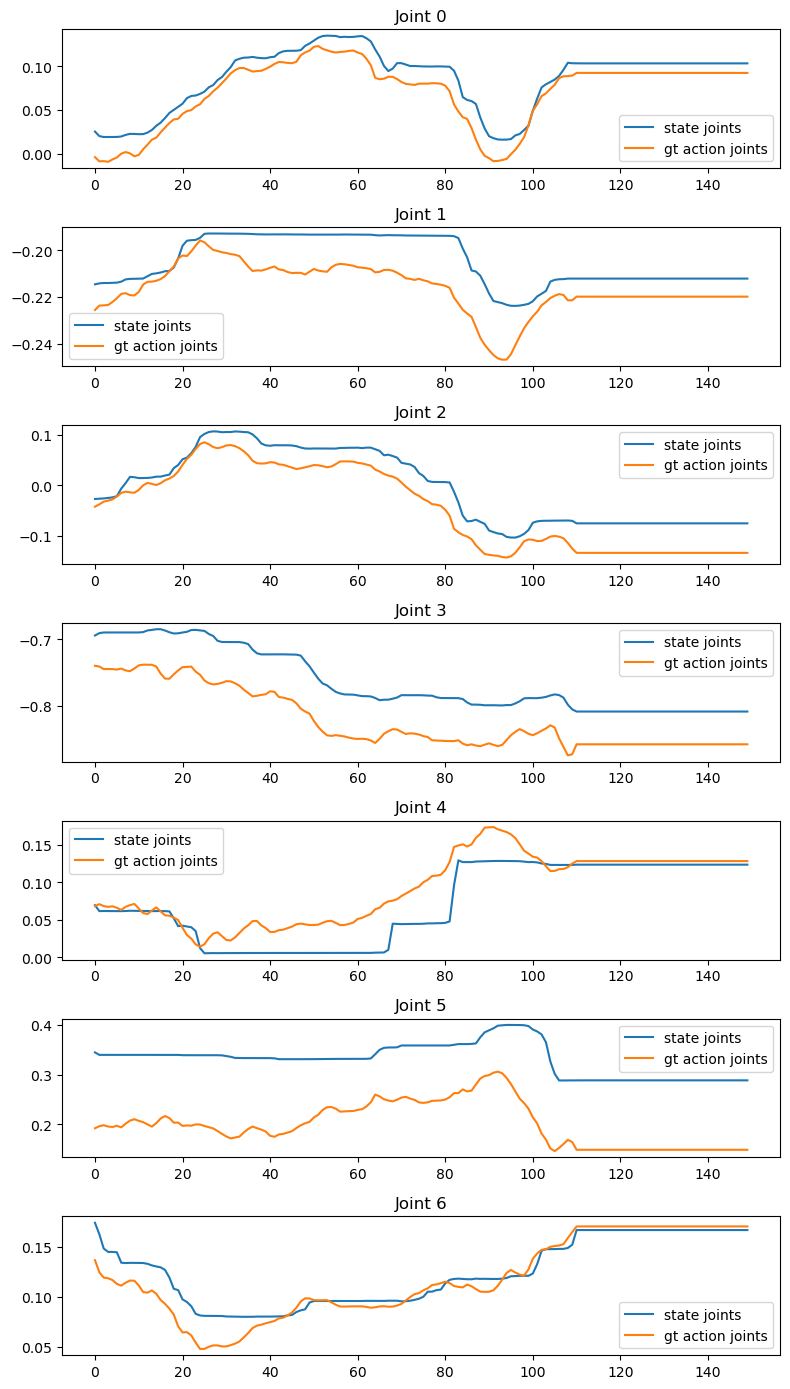

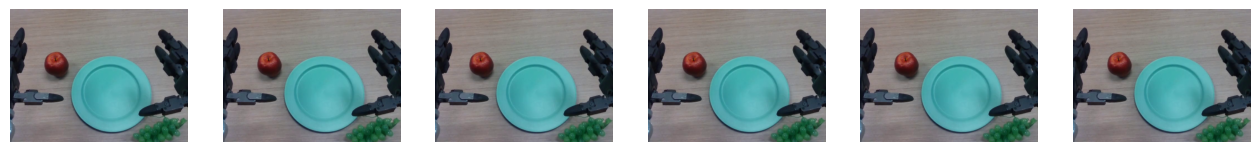

In [13]:
import matplotlib.pyplot as plt

traj_id = 0
max_steps = 150

state_joints_across_time = []
gt_action_joints_across_time = []
images = []

sample_images = 6

for step_count in range(max_steps):
    data_point = dataset.get_step_data(traj_id, step_count)
    state_joints = data_point["state.right_arm"][0]
    gt_action_joints = data_point["action.right_arm"][0]
    
   
    state_joints_across_time.append(state_joints)
    gt_action_joints_across_time.append(gt_action_joints)

    # We can also get the image data
    if step_count % (max_steps // sample_images) == 0:
        image = data_point["video.rs_view"][0]
        images.append(image)

# Size is (max_steps, num_joints == 7)
state_joints_across_time = np.array(state_joints_across_time)
gt_action_joints_across_time = np.array(gt_action_joints_across_time)


# Plot the joint angles across time
fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(8, 2*7))

for i, ax in enumerate(axes):
    ax.plot(state_joints_across_time[:, i], label="state joints")
    ax.plot(gt_action_joints_across_time[:, i], label="gt action joints")
    ax.set_title(f"Joint {i}")
    ax.legend()

plt.tight_layout()
plt.show()


# Plot the images in a row
fig, axes = plt.subplots(nrows=1, ncols=sample_images, figsize=(16, 4))

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.axis("off")
    

Now we can run the policy from the pretrained checkpoint.

In [19]:
step_data.keys()

dict_keys(['video.rs_view', 'state.left_arm', 'state.right_arm', 'state.left_hand', 'state.right_hand', 'action.left_arm', 'action.right_arm', 'action.left_hand', 'action.right_hand', 'annotation.human.task_description'])

In [15]:
predicted_action = policy.get_action(step_data)
for key, value in predicted_action.items():
    print(key, value.shape)

action.left_arm (16, 7)
action.right_arm (16, 7)
action.left_hand (16, 7)
action.right_hand (16, 7)


### Understanding the Action Output

Each joint in the action output has a shape of (16, N) where N is the degree of freedom for the joint.
- 16 represents the action horizon (predictions for timesteps t, t+1, t+2, ..., t+15)

For each arm (left and right):
- 7 arm joints:
  - Shoulder pitch
  - Shoulder roll
  - Shoulder yaw
  - Elbow pitch
  - Wrist yaw
  - Wrist roll
  - Wrist pitch

For each hand (left and right):
- 6 finger joints:
  - Little finger
  - Ring finger
  - Middle finger
  - Index finger
  - Thumb rotation
  - Thumb bending

For the waist
- 3 joints:
  - torso waist yaw
  - torso waist pitch
  - torso waist roll
